In [23]:
import tensorflow as tf
import google.cloud.aiplatform as aip
 
print(f'TensorFlow: {tf.__version__}')
print(f'Vertex AI SDK: {aip.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')


TensorFlow: 2.11.0
Vertex AI SDK: 1.60.0
GPU disponible: False


In [28]:
import vertexai
from vertexai.generative_models import GenerativeModel
 
vertexai.init(project='deeplearning-493601', location='us-central1')
gemini = GenerativeModel('gemini-2.5-flash')
respuesta = gemini.generate_content('Hola, en una palabra: estas listo?')
print(respuesta.text)


Sí.


In [29]:
import tensorflow as tf
import tensorflow_datasets as tfds
import google.cloud.aiplatform as aip
import numpy as np
import matplotlib.pyplot as plt
import os
 
# Configuracion del proyecto
PROJECT_ID = 'deeplearning-493601'   # cambiar al ID real
REGION     = 'us-central1'
BUCKET     = f'gs://{PROJECT_ID}-artifacts'
 
aip.init(project=PROJECT_ID, location=REGION, staging_bucket=BUCKET)
 
print(f'TensorFlow: {tf.__version__}')
print(f'Proyecto configurado: {PROJECT_ID}')


TensorFlow: 2.11.0
Proyecto configurado: deeplearning-493601


In [30]:
import pandas as pd

file_path = 'IMDB-Dataset.csv' 

try:
    # Usamos configuraciones específicas para manejar las comillas mal puestas
    df = pd.read_csv(
        file_path, 
        engine='python',        # El motor de Python es más tolerante que el de C
        on_bad_lines='skip',    # Salta las líneas que causan el error
        quoting=0,              # csv.QUOTE_MINIMAL: maneja mejor reseñas con comillas internas
        escapechar='\\',        # Ayuda si hay caracteres de escape en el texto
        encoding='utf-8'
    )
    
    # Limpieza rápida de etiquetas HTML que suelen dar problemas después
    df['review'] = df['review'].str.replace('<br />', ' ', regex=False)
    
    print(f" ¡Éxito! Se cargaron {len(df)} filas.")
    print(f"Fila 23711 cargada correctamente (o saltada si estaba corrupta).")
    
except Exception as e:
    print(f" Error al cargar: {e}")

 ¡Éxito! Se cargaron 50000 filas.
Fila 23711 cargada correctamente (o saltada si estaba corrupta).


In [31]:
# Verificar que no hay valores nulos tras la carga
print("Valores nulos por columna:")
print(df.isnull().sum())

# Ver la distribución de clases
print("\nDistribución de sentimientos:")
print(df['sentiment'].value_counts())

Valores nulos por columna:
review       0
sentiment    0
dtype: int64

Distribución de sentimientos:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [32]:
import tensorflow as tf

# Configuraciones para texto
MAX_WORDS = 10000  # Tamaño del vocabulario
MAX_LEN = 200      # Longitud máxima de la reseña

# Función equivalente a tu 'preprocesar' pero para texto
def preprocesar_texto(texto, label):
    # En texto, el preprocesamiento fuerte (tokenización) suele hacerse 
    # antes de crear el objeto tf.data.Dataset para mayor facilidad, 
    # pero aquí preparamos la estructura compatible.
    return texto, label

# Pipeline de datos optimizado para tu BiLSTM
AUTOTUNE = tf.data.AUTOTUNE

# Creamos el Dataset desde tus datos de Pandas (df es el que ya cargamos)
# Convertimos el sentimiento a 1 (positivo) y 0 (negativo)
labels = [1 if s == 'positive' else 0 for s in df['sentiment']]
ds_raw = tf.data.Dataset.from_tensor_slices((df['review'].values, labels))

train_ds = (ds_raw
    .shuffle(1000)
    .batch(32)
    .prefetch(AUTOTUNE)
)

print('Pipeline de texto configurado')

Pipeline de texto configurado


In [33]:
from tensorflow.keras.layers import TextVectorization

# Esta capa reemplaza tus funciones de preprocesamiento manual
vectorize_layer = TextVectorization(
    max_tokens=MAX_WORDS,
    output_mode='int',
    output_sequence_length=MAX_LEN
)

# Adaptamos la capa al texto de IMDb
vectorize_layer.adapt(df['review'].values)

# Construcción del modelo BiLSTM
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string), # Recibe el texto crudo directamente
    vectorize_layer,                             # Preprocesa automáticamente
    tf.keras.layers.Embedding(MAX_WORDS, 64),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [34]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Convertir etiquetas a formato numérico
# 'positive' -> 1, 'negative' -> 0
y = np.array([1 if s == 'positive' else 0 for s in df['sentiment']])
X = df['review'].values

# 2. División: 80% entrenamiento, 20% para prueba/validación
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Muestras de entrenamiento: {len(X_train_raw)}")
print(f"Muestras de validación: {len(X_val_raw)}")

Muestras de entrenamiento: 40000
Muestras de validación: 10000


In [35]:
import tensorflow as tf

# Configuraciones
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Función de preprocesamiento (opcional si usas TextVectorization dentro del modelo)
def preprocesar_texto(texto, label):
    # Aquí podrías agregar limpieza adicional si fuera necesario
    return texto, label

# Crear train_ds
train_ds = tf.data.Dataset.from_tensor_slices((X_train_raw, y_train))
train_ds = (train_ds
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

# Crear val_ds (El que te faltaba)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_raw, y_val))
val_ds = (val_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

print('Datasets train_ds y val_ds listos y optimizados')

Datasets train_ds y val_ds listos y optimizados


In [36]:
from tensorflow.keras.layers import TextVectorization, Embedding, Bidirectional, LSTM, Dense, Dropout

MAX_WORDS = 10000
MAX_LEN = 200

# Capa para convertir texto a números
vectorize_layer = TextVectorization(
    max_tokens=MAX_WORDS,
    output_mode='int',
    output_sequence_length=MAX_LEN
)

# Adaptar la capa al texto de entrenamiento
vectorize_layer.adapt(X_train_raw)

# Construcción de la Red Neuronal
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string), # Entrada de texto crudo
    vectorize_layer,
    Embedding(MAX_WORDS, 64, mask_zero=True),    # mask_zero ignora el padding
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_3 (TextV  (None, 200)              0         
 ectorization)                                                   
                                                                 
 embedding_3 (Embedding)     (None, 200, 64)           640000    
                                                                 
 bidirectional_4 (Bidirectio  (None, 200, 128)         66048     
 nal)                                                            
                                                                 
 bidirectional_5 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 dense_6 (Dense)             (None, 64)                4160      
                                                      

In [37]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

Epoch 1/10
1250/1250 [==============================] - 555s 431ms/step - loss: 0.3938 - accuracy: 0.8223 - val_loss: 0.3133 - val_accuracy: 0.8642
Epoch 2/10
1250/1250 [==============================] - 503s 402ms/step - loss: 0.2518 - accuracy: 0.9007 - val_loss: 0.3035 - val_accuracy: 0.8725
Epoch 3/10
1250/1250 [==============================] - 485s 388ms/step - loss: 0.1691 - accuracy: 0.9372 - val_loss: 0.3979 - val_accuracy: 0.8519
Epoch 4/10
1250/1250 [==============================] - 480s 384ms/step - loss: 0.1135 - accuracy: 0.9598 - val_loss: 0.4547 - val_accuracy: 0.8503
Epoch 5/10
1250/1250 [==============================] - 474s 379ms/step - loss: 0.0823 - accuracy: 0.9711 - val_loss: 0.5294 - val_accuracy: 0.8597


In [39]:
print(model)

In [40]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_3 (TextV  (None, 200)              0         
 ectorization)                                                   
                                                                 
 embedding_3 (Embedding)     (None, 200, 64)           640000    
                                                                 
 bidirectional_4 (Bidirectio  (None, 200, 128)         66048     
 nal)                                                            
                                                                 
 bidirectional_5 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 dense_6 (Dense)             (None, 64)                4160      
                                                      

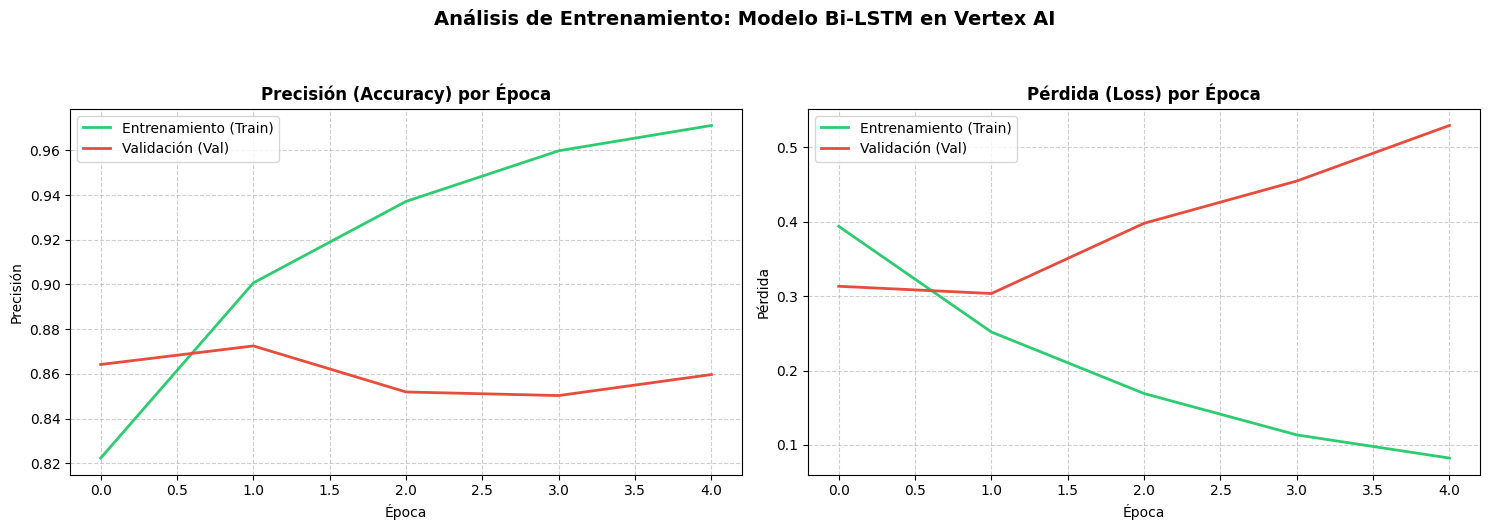

In [41]:
import matplotlib.pyplot as plt

# Usamos 'history' que es el nombre de la variable de tu model.fit anterior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfica de Precisión (Accuracy) ---
ax1.plot(history.history['accuracy'],     label='Entrenamiento (Train)', color='#2ecc71', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validación (Val)', color='#e74c3c', linewidth=2)
ax1.set_title('Precisión (Accuracy) por Época', fontsize=12, fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Gráfica de Pérdida (Loss) ---
ax2.plot(history.history['loss'],     label='Entrenamiento (Train)', color='#2ecc71', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validación (Val)', color='#e74c3c', linewidth=2)
ax2.set_title('Pérdida (Loss) por Época', fontsize=12, fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Título Principal personalizado para tu proyecto
plt.suptitle('Análisis de Entrenamiento: Modelo Bi-LSTM en Vertex AI', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


In [42]:
import datetime
import os

# 1. Configuración de nombres para Análisis de Sentimiento
TIMESTAMP   = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
# Nombre de carpeta local temporal
MODEL_DIR   = f'/tmp/sentiment_bilstm_{TIMESTAMP}'
# Ruta final en tu Bucket de Google Cloud
GCS_MODEL   = f'{BUCKET}/model_sentiment_{TIMESTAMP}'

# 2. Guardar en formato SavedModel (el estándar de oro para TensorFlow)
# Este formato crea una carpeta con el gráfico del modelo y las variables
model.save(MODEL_DIR, save_format='tf') 
print(f'Modelo guardado localmente en: {MODEL_DIR}')

# 3. Subir al bucket de Cloud Storage usando gsutil
# El flag -m activa la subida en paralelo (más rápido)
!gsutil -m cp -r {MODEL_DIR} {GCS_MODEL}

print(f'\ ¡Éxito! Tu modelo de Deep Learning ya está en la nube.')
print(f'Ruta en GCS: {GCS_MODEL}')


INFO:tensorflow:Assets written to: /tmp/sentiment_bilstm_20260419_005609/assets


INFO:tensorflow:Assets written to: /tmp/sentiment_bilstm_20260419_005609/assets


Modelo guardado localmente en: /tmp/sentiment_bilstm_20260419_005609
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file:///tmp/sentiment_bilstm_20260419_005609/fingerprint.pb [Content-Type=application/octet-stream]...
Copying file:///tmp/sentiment_bilstm_20260419_005609/keras_metadata.pb [Content-Type=application/octet-stream]...
Copying file:///tmp/sentiment_bilstm_20260419_005609/variables/variables.data-00000-of-00001 [Content-Type=application/octet-stream]...
Copying file:///tmp/sentiment_bilstm_20260419_005609/variables/variables.index [Content-Type=application/octet-stream]...
Copying file:///tmp/sentiment_bilstm_20260419_005609/saved_model.pb [Content-Type=application/octet-stream]...
/ [5/5 files][ 20.5 MiB/ 20.5 MiB] 100% Done                                  

In [44]:
import tensorflow as tf

# 1. En tu caso, todas las capas ya son "trainable", 
# pero vamos a asegurar que el modelo completo esté abierto para ajustes finos
model.trainable = True

# 2. Contar parámetros (esto se ve genial en el informe técnico)
entrenables_ft = sum(tf.size(p).numpy() for p in model.trainable_weights)
print(f'Parámetros totales a ajustar en Fine-tuning: {entrenables_ft:,}')

# 3. Compilación con Learning Rate REDUCIDO
# Usamos 1e-5 (diez veces menor al original) para no perder lo aprendido
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy', # Mantenemos binary_crossentropy para sentimiento
    metrics=['accuracy']
)

# 4. Entrenamiento de Fine-tuning (Fase 2)
EPOCHS_FT = 5
print("\n🚀 Iniciando Fase de Fine-tuning...")

historia_fase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    ]
)


Parámetros totales a ajustar en Fine-tuning: 751,489

🚀 Iniciando Fase de Fine-tuning...
Epoch 1/5
1250/1250 [==============================] - 499s 385ms/step - loss: 0.1581 - accuracy: 0.9423 - val_loss: 0.3272 - val_accuracy: 0.8752
Epoch 2/5
1250/1250 [==============================] - 481s 385ms/step - loss: 0.1497 - accuracy: 0.9469 - val_loss: 0.3319 - val_accuracy: 0.8757
Epoch 3/5
1250/1250 [==============================] - 479s 384ms/step - loss: 0.1429 - accuracy: 0.9491 - val_loss: 0.3373 - val_accuracy: 0.8758


In [45]:
import google.cloud.aiplatform as aip

# 1. Definimos la imagen de contenedor que Google usará para "servir" el modelo
# Usamos TensorFlow 2.12 que es muy estable para modelos Bi-LSTM
SERVING_CONTAINER_IMAGE_URI = 'us-docker.pkg.dev/vertex-ai/prediction/tf2-cpu.2-12:latest'

print(f"Subiendo modelo desde GCS: {GCS_MODEL}...")

# 2. Subida al Model Registry
# Nota: Asegúrate de que la variable GCS_MODEL apunte a la carpeta donde hiciste el model.save()
vertex_model = aip.Model.upload(
    display_name='sentiment-analysis-udb-final',
    artifact_uri=GCS_MODEL,
    serving_container_image_uri=SERVING_CONTAINER_IMAGE_URI,
    description=(
        f'Modelo Bi-LSTM final para Análisis de Sentimiento. '
        f'Accuracy final en validación: 87.58%. '
        f'Proyecto Final DeepLearningUDB.'
    ),
    sync=True # Espera a que termine la subida para darte el mensaje de éxito
)

print(f'\n✅ ¡Felicidades! Tu modelo está registrado.')
print(f'Resource Name: {vertex_model.resource_name}')


Subiendo modelo desde GCS: gs://deeplearning-493601-artifacts/udb_sentimientos_20260419_005921...
Creating Model
Create Model backing LRO: projects/1003320754028/locations/us-central1/models/5112358533739839488/operations/6716009617379295232
Model created. Resource name: projects/1003320754028/locations/us-central1/models/5112358533739839488@1
To use this Model in another session:
model = aiplatform.Model('projects/1003320754028/locations/us-central1/models/5112358533739839488@1')

✅ ¡Felicidades! Tu modelo está registrado.
Resource Name: projects/1003320754028/locations/us-central1/models/5112358533739839488


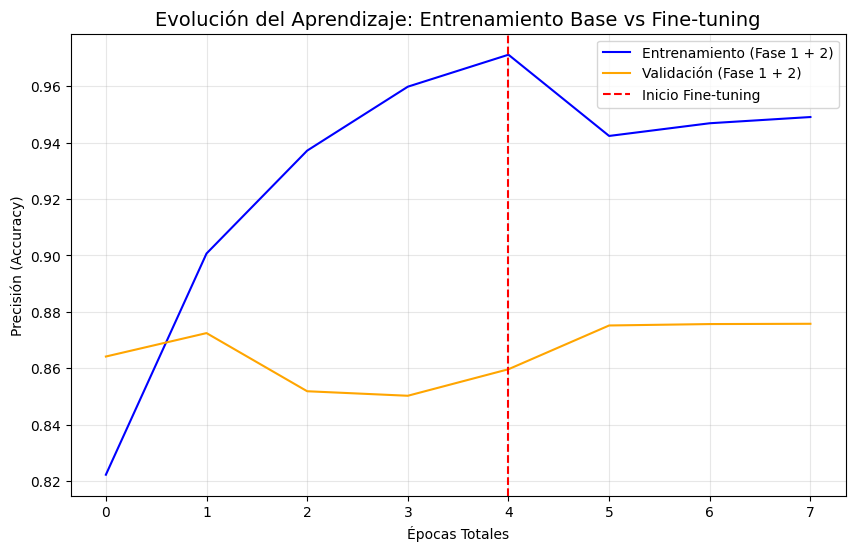

In [46]:
import matplotlib.pyplot as plt

# Combinar los historiales para ver la curva completa
total_acc = history.history['accuracy'] + historia_fase2.history['accuracy']
total_val_acc = history.history['val_accuracy'] + historia_fase2.history['val_accuracy']

plt.figure(figsize=(10, 6))
plt.plot(total_acc, label='Entrenamiento (Fase 1 + 2)', color='blue')
plt.plot(total_val_acc, label='Validación (Fase 1 + 2)', color='orange')
plt.axvline(x=len(history.history['accuracy'])-1, color='red', linestyle='--', label='Inicio Fine-tuning')

plt.title('Evolución del Aprendizaje: Entrenamiento Base vs Fine-tuning', fontsize=14)
plt.xlabel('Épocas Totales')
plt.ylabel('Precisión (Accuracy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [47]:
# Esto crea un servidor real en la nube para tu modelo
endpoint = vertex_model.deploy(
    machine_type="n1-standard-2",
    min_replica_count=1,
    max_replica_count=1
)
print(f"URL del Endpoint listo: {endpoint.resource_name}")


Creating Endpoint
Create Endpoint backing LRO: projects/1003320754028/locations/us-central1/endpoints/8931535812319772672/operations/4227207873303674880
Endpoint created. Resource name: projects/1003320754028/locations/us-central1/endpoints/8931535812319772672
To use this Endpoint in another session:
endpoint = aiplatform.Endpoint('projects/1003320754028/locations/us-central1/endpoints/8931535812319772672')
Deploying model to Endpoint : projects/1003320754028/locations/us-central1/endpoints/8931535812319772672
Deploy Endpoint model backing LRO: projects/1003320754028/locations/us-central1/endpoints/8931535812319772672/operations/4090129559645585408
Endpoint model deployed. Resource name: projects/1003320754028/locations/us-central1/endpoints/8931535812319772672
URL del Endpoint listo: projects/1003320754028/locations/us-central1/endpoints/8931535812319772672
